<a href="https://colab.research.google.com/github/zaidan-khairiazhar/machine-learning-python/blob/main/ML_Method_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== DATA WEATHER ===
     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No

Jumlah Data Latih: 9
Jumlah Data Uji: 5

=== HASIL EVALUASI ===
Akurasi Model: 80.00%


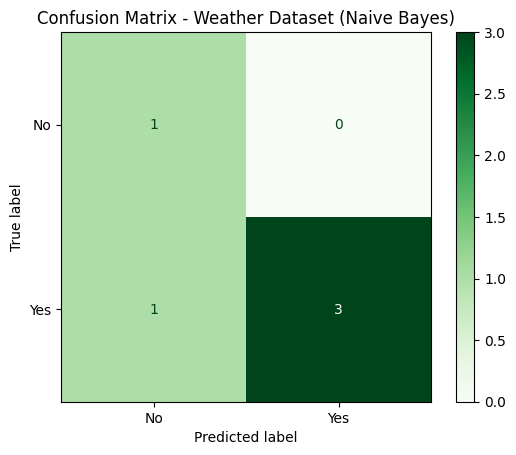

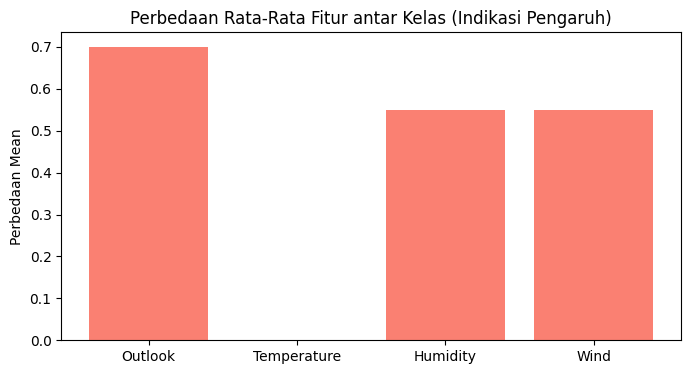


Prediksi Cuaca Baru: No

=== ANALISIS ===
- GaussianNB tetap cocok karena fitur sudah berbentuk numerik.
- Fitur dengan perbedaan mean terbesar lebih berpengaruh pada hasil klasifikasi.
- Cek confusion matrix untuk melihat kelas mana yang sering salah diprediksi.


In [1]:
# ===============================================================
# PRAKTIKUM MACHINE LEARNING - MODUL 4
# KLASIFIKASI DENGAN NAIVE BAYES (Versi Berbeda)
# Dataset: Weather.csv (dibuat otomatis)
# ===============================================================

# 1️ Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 2️ Membuat Dataset Weather
data_weather = {
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast",
                "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"],
    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                    "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Wind": ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
             "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Strong"],
    "Play": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
             "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}

df = pd.DataFrame(data_weather)
df.to_csv("Weather.csv", index=False)
print("=== DATA WEATHER ===")
print(df)

# 3️ Preprocessing Data
# Memisahkan fitur dan label
X = df.drop("Play", axis=1)
y = df["Play"]

# Mengubah nilai kategorikal fitur menjadi numerik menggunakan LabelEncoder
feature_encoders = {}
for col in X.columns:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])
    feature_encoders[col] = encoder # Store encoder for later use

# Mengubah nilai kategorikal label menjadi numerik
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


# 4️ Split Data Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)
print("\nJumlah Data Latih:", len(X_train))
print("Jumlah Data Uji:", len(X_test))

# 5️ Membuat Model dan Melatih
model = GaussianNB()
model.fit(X_train, y_train)

# 6️ Prediksi dan Evaluasi
y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)
print("\n=== HASIL EVALUASI ===")
print("Akurasi Model: {:.2f}%".format(akurasi * 100))

# 7️ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix - Weather Dataset (Naive Bayes)")
plt.show()

# 8️ Analisis Pengaruh Fitur
# Gunakan nilai rata-rata (theta_) dari masing-masing fitur untuk tiap kelas
# Ensure the number of features matches the trained model
if model.theta_.shape[1] == X.shape[1]:
    feature_mean_diff = np.abs(model.theta_[0] - model.theta_[1])
    plt.figure(figsize=(8,4))
    plt.bar(X.columns, feature_mean_diff, color="salmon")
    plt.title("Perbedaan Rata-Rata Fitur antar Kelas (Indikasi Pengaruh)")
    plt.ylabel("Perbedaan Mean")
    plt.show()
else:
    print("\nSkipping feature influence analysis: Number of features in model and data mismatch.")


# 9️ Prediksi Kasus Baru
# Outlook=Sunny, Temperature=Cool, Humidity=Normal, Wind=Strong
# (Gunakan kode numerik sesuai hasil encoding di awal)

# Create a dictionary for the new sample and encode it using the fitted encoders
sample_data = {
    "Outlook": ["Sunny"],
    "Temperature": ["Cool"],
    "Humidity": ["Normal"],
    "Wind": ["Strong"]
}

sample_df = pd.DataFrame(sample_data)

# Encode the new sample using the stored encoders
encoded_sample = pd.DataFrame()
for col, encoder in feature_encoders.items():
    encoded_sample[col] = encoder.transform(sample_df[col])

prediksi = model.predict(encoded_sample)
label_pred = label_encoder.inverse_transform(prediksi)
print("\nPrediksi Cuaca Baru:", label_pred[0])

#  Analisis Hasil
print("\n=== ANALISIS ===")
print("- GaussianNB tetap cocok karena fitur sudah berbentuk numerik.")
print("- Fitur dengan perbedaan mean terbesar lebih berpengaruh pada hasil klasifikasi.")
print("- Cek confusion matrix untuk melihat kelas mana yang sering salah diprediksi.")